mount the drive to load data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the CSV games file

In [2]:
game_file = '/content/drive/MyDrive/Colab_Notebooks/live_project/game/Games-Calculated.csv'



Import the libraries

In [25]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [39]:
def buildModel():
  model=keras.models.Sequential([
      keras.layers.Dense(32,activation='relu',input_shape=[4]),
      keras.layers.Dense(32,activation='relu'),
      keras.layers.Dense(1)
      ])
  model.compile(optimizer='rmsprop',loss='mean_squared_error',metrics=['accuracy','MeanAbsoluteError','MeanSquaredError'])

  return model


In [4]:
column_names = ['Date','HomeTeam','HomeScore','AwayTeam','AwayScore',
                'HomeScoreAverage','HomeDefenseAverage','AwayScoreAverage','AwayDefenseAverage',
                'Result']
data = pd.read_csv(game_file,names=column_names)


In [5]:
data.head(2)

,Date,HomeTeam,HomeScore,AwayTeam,AwayScore,HomeScoreAverage,HomeDefenseAverage,AwayScoreAverage,AwayDefenseAverage,Result
0,2015-11-13,Hawaii,87,Montana State,76,87.0,76.0,76.0,87.0,11
1,2015-11-13,Eastern Michigan,70,Vermont,50,70.0,50.0,50.0,70.0,20


We will remove the columns which we dont need in training

In [10]:
updated_data=data.drop(['Date','HomeTeam','HomeScore','AwayTeam','AwayScore'], axis=1)
updated_data.shape

(20160, 5)

In [7]:
updated_data.head(2)

,HomeScoreAverage,HomeDefenseAverage,AwayScoreAverage,AwayDefenseAverage,Result
0,87.0,76.0,76.0,87.0,11
1,70.0,50.0,50.0,70.0,20


We have to break the data in 80:20 split for train and test

In [27]:
trainX=updated_data.sample(frac=0.8,random_state=0)

In [28]:
trainX.shape

(16128, 5)

In [29]:
testX=updated_data.drop(trainX.index)

In [30]:
testX.shape

(4032, 5)

Now we have 80% train data and 20% test data, and now we need to build target for test and train

In [31]:
trainY=trainX.pop('Result')

In [33]:
testY=testX.pop('Result')


We will normalize the data in both test and train. We will create z_score_standardization

In [35]:
def z_score_standardization(df):
    df_scaled = df.copy()
    for column in df.columns:
        df_scaled[column] = (df[column] - df[column].mean()) / df[column].std()
    return df_scaled

In [36]:
scaledTrainX=z_score_standardization(trainX)

In [37]:
scaledTestX=z_score_standardization(testX)

We will create model and fit the data

In [42]:
model=buildModel()
history = model.fit(scaledTrainX, trainY, epochs=100, validation_split=0.2)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - MeanAbsoluteError: 10.3541 - MeanSquaredError: 176.6753 - accuracy: 0.0121 - loss: 176.6753 - val_MeanAbsoluteError: 7.9699 - val_MeanSquaredError: 104.6308 - val_accuracy: 0.0115 - val_loss: 104.6308
Epoch 2/100
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - MeanAbsoluteError: 7.9981 - MeanSquaredError: 104.9987 - accuracy: 0.0155 - loss: 104.9987 - val_MeanAbsoluteError: 7.9189 - val_MeanSquaredError: 103.2933 - val_accuracy: 0.0121 - val_loss: 103.2933
Epoch 3/100
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MeanAbsoluteError: 7.9459 - MeanSquaredError: 103.2335 - accuracy: 0.0161 - loss: 103.2335 - val_MeanAbsoluteError: 7.8945 - val_MeanSquaredError: 102.8483 - val_accuracy: 0.0133 - val_loss: 102.8483
Epoch 4/100
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MeanAbsoluteError: 7.9000 - MeanSquaredError: 102.4400 - accuracy: 0.0162 - loss: 102.4400 - val_MeanAbsoluteError: 7.8820 - val_MeanSquaredError: 102.6528 - val_accuracy: 0.0130 - val_loss: 

# Test the network against your testing data set

In [43]:

test_loss, mae, test_acc, mse = model.evaluate(scaledTestX, testY)

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MeanAbsoluteError: 7.3928 - MeanSquaredError: 93.3554 - accuracy: 0.0240 - loss: 93.3554


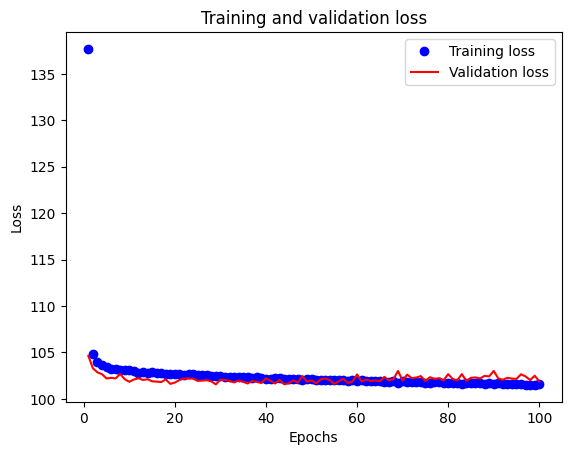

In [52]:

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [53]:
history_dict = history.history


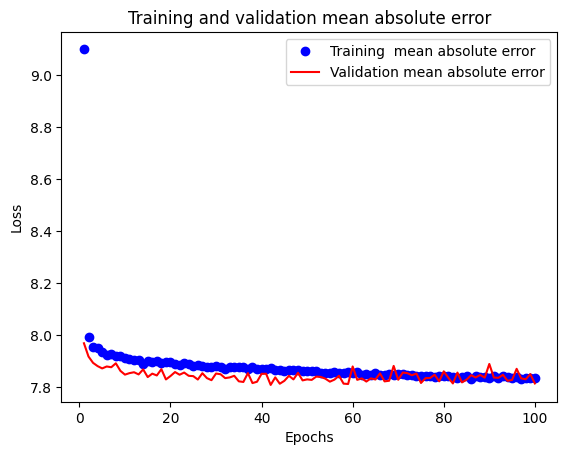

In [54]:

abs_error = history_dict["MeanAbsoluteError"]
val_abs_error = history_dict["val_MeanAbsoluteError"]
epochs = range(1, len(abs_error) + 1)
plt.plot(epochs, abs_error, "bo", label="Training  mean absolute error")
plt.plot(epochs, val_abs_error, "r", label="Validation mean absolute error")
plt.title("Training and validation mean absolute error")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()